In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [3]:
df = pd.read_sql("SELECT * FROM NearsestSample", conn)

df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)].reset_index(drop=True)

In [4]:
# Kiểm tra dữ liệu thô
print(df.shape)
print(df.head().T)
print(df.sample(5).T)
# Kiểm tra duplicate
print(df.duplicated().sum())
df = df.drop_duplicates()

(10956, 13)
                    0          1          2          3          4
id                  6         17         20         30         37
y               134.9      136.1      135.9      135.6      135.2
x1             29.965       56.0     58.052    481.645    561.071
x2          23.820369  11.373624  11.438215  22.734497  11.987971
x3               26.1       26.6       26.5       26.4       26.2
x4                5.0        4.9        4.9        5.0        5.0
x5                7.2  54.178596        7.7        7.6        7.3
x6                7.9        8.4        8.4        8.3        8.0
x7                NaN       0.18       0.17       0.18        NaN
x8           24.70561  25.515699  25.326576   25.15057  17.841043
x9               28.1        7.4        7.4        7.4       28.1
SpatialDim        ALB        ALB        ALB        ALB        ALB
TimeDim          2010       2015       2014       2013       2011
                6691       9968       2920       10585      9808

In [5]:
df = df.drop(columns=["id","x7","SpatialDim"], errors="ignore")
df.columns = [
    'cardiovascular_diseases',
    'air_pollution',
    'alcohol_consumption',
    'BMI',
    'cholesterol',
    'diabetes',
    'glucose',
    'physical_activities',
    'tobacco',
    'time'
]

In [6]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  float64
 1   air_pollution            10890 non-null  float64
 2   alcohol_consumption      10735 non-null  float64
 3   BMI                      10956 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   time                     10956 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 856.1 KB


In [7]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution               66
alcohol_consumption        221
BMI                          0
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
time                         0
dtype: int64

In [8]:
missing_ratio = df.isnull().mean()*100
print(missing_ratio)

cardiovascular_diseases    0.00000
air_pollution              0.60241
alcohol_consumption        2.01716
BMI                        0.00000
cholesterol                0.00000
diabetes                   0.00000
glucose                    0.00000
physical_activities        0.00000
tobacco                    0.00000
time                       0.00000
dtype: float64


In [9]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10956.0,55.593244,35.512469,8.701838,32.768090,40.400000,62.100000,1.375000e+02
air_pollution,10956.0,8290.686407,319532.735705,0.000000,51.066000,193.716500,582.009500,2.509519e+07
alcohol_consumption,10956.0,41.429338,19.257525,2.680089,26.664454,40.181983,52.406960,9.921560e+01
BMI,10956.0,22.424149,17.616987,0.238787,7.450371,22.200000,27.200000,9.247079e+01
cholesterol,10956.0,2.903514,1.426160,0.800000,1.300000,3.300000,4.000000,5.300000e+00
diabetes,10956.0,16.683322,16.735358,2.800000,5.694480,8.000000,20.600000,8.310288e+01
glucose,10956.0,8.657804,4.239293,2.100000,5.900000,8.000000,9.800000,2.980000e+01
physical_activities,10956.0,26.063816,11.766169,3.335438,17.580842,23.772923,32.636906,6.920515e+01
tobacco,10956.0,23.755696,14.737694,0.000000,12.475000,23.000000,32.800000,7.700000e+01
time,10956.0,2012.500000,1.707903,2010.000000,2011.000000,2012.500000,2014.000000,2.015000e+03


<Axes: xlabel='air_pollution', ylabel='Count'>

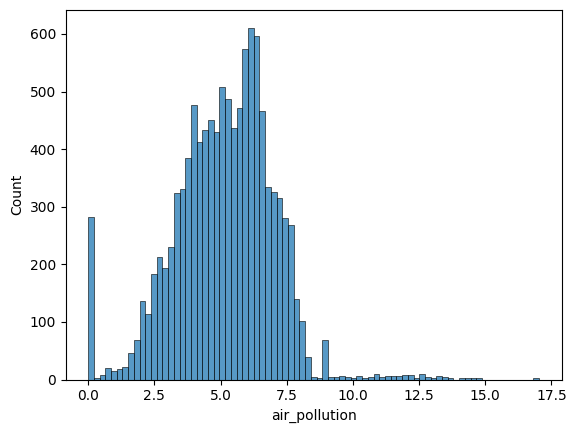

In [11]:
df['air_pollution'] = np.log1p(df['air_pollution'])
sns.histplot(df['air_pollution'])

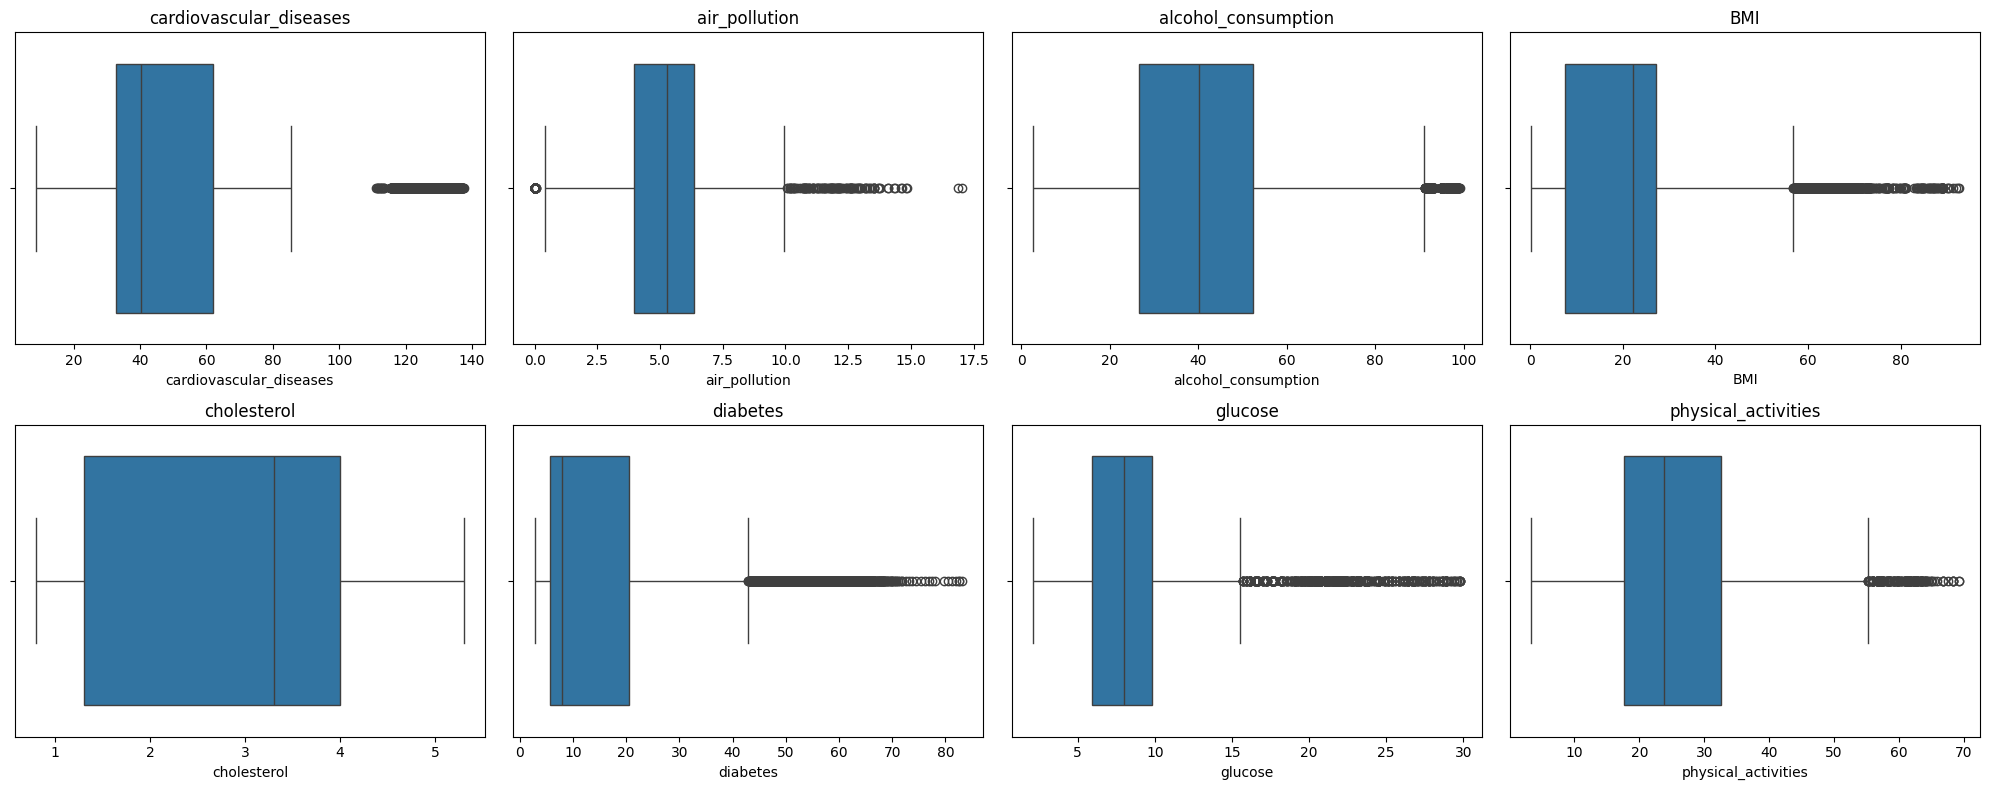

In [12]:
cols = df.columns[:-1]

plt.figure(figsize=(20,8))

for i, col in enumerate(cols[:8]):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

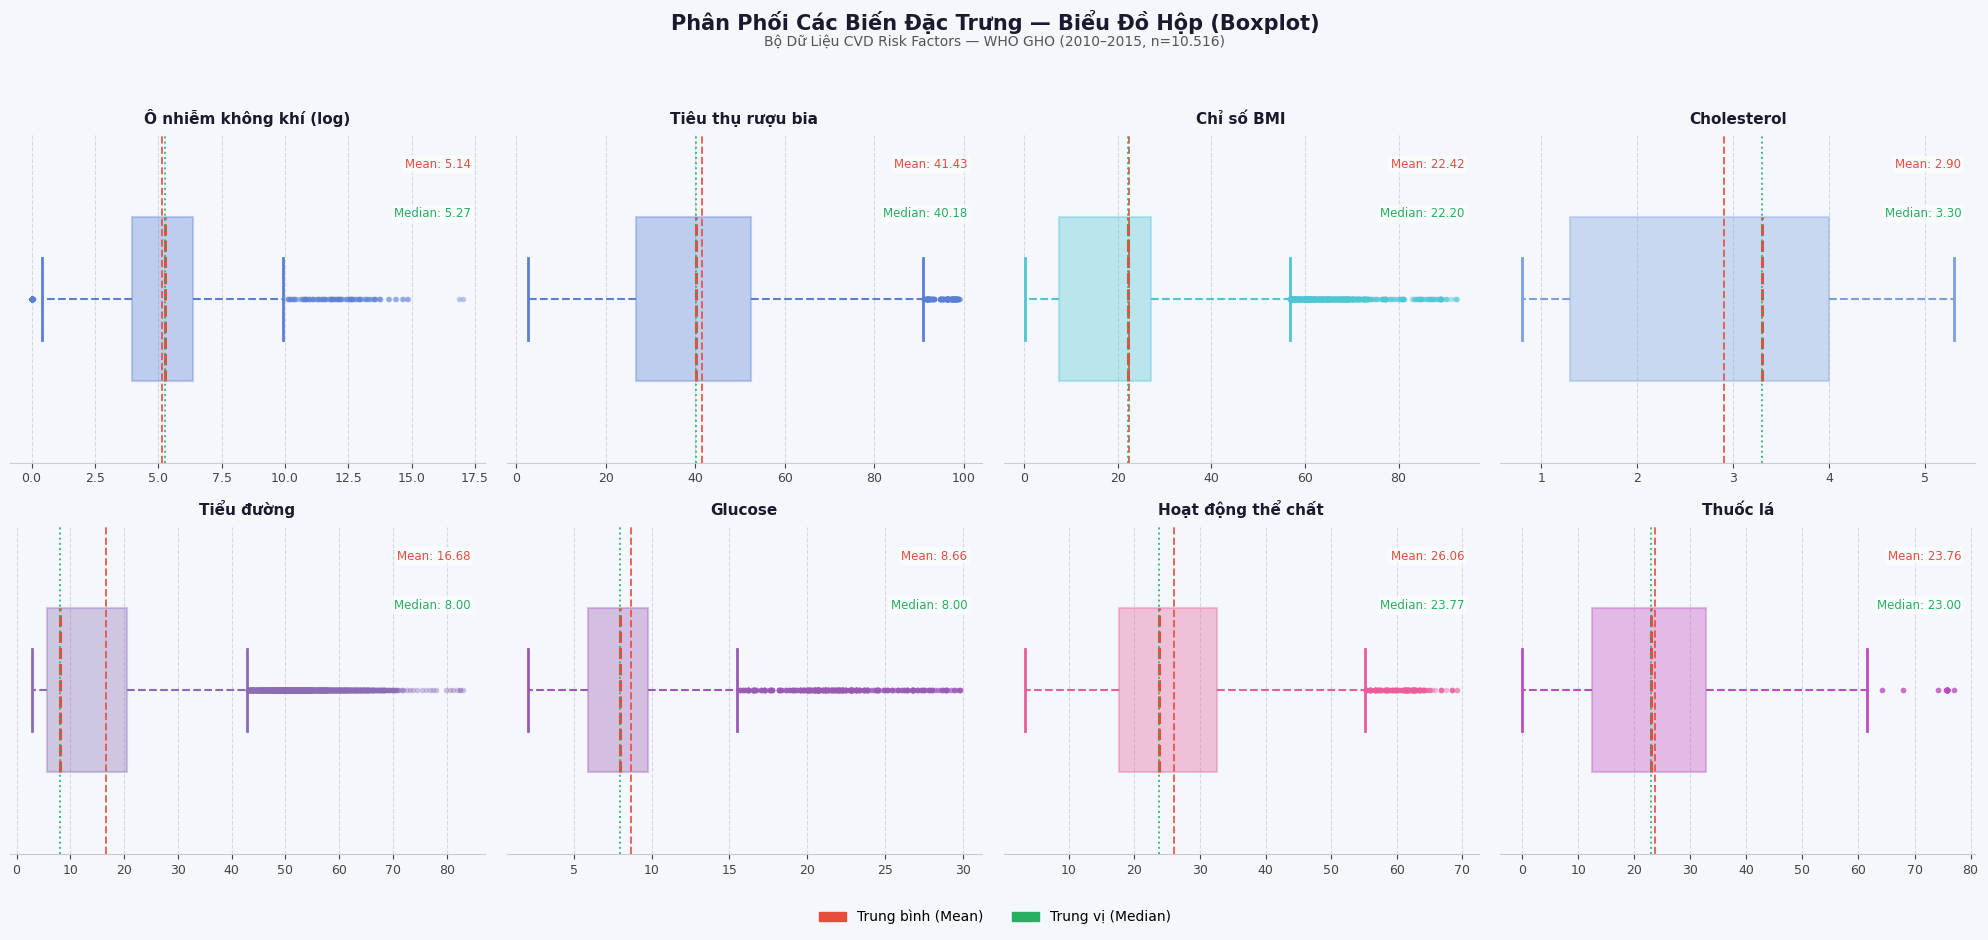

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# --- Mapping tên biến → tiếng Việt + màu sắc ---
var_config = {
    'air_pollution':          {'label': 'Ô nhiễm không khí (log)', 'color': '#5B7FD4'},
    'alcohol_consumption':    {'label': 'Tiêu thụ rượu bia',        'color': '#5B7FD4'},
    'BMI':                    {'label': 'Chỉ số BMI',               'color': '#4EC6D4'},
    'cholesterol':            {'label': 'Cholesterol',              'color': '#7B9FE0'},
    'diabetes':               {'label': 'Tiểu đường',               'color': '#8B6BB5'},
    'glucose':                {'label': 'Glucose',                  'color': '#9B59B6'},
    'physical_activities':    {'label': 'Hoạt động thể chất',       'color': '#E85D9A'},
    'tobacco':                {'label': 'Thuốc lá',                 'color': '#C04BC0'},
}

cols = [c for c in var_config if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#F4F7FB')
axes = axes.flatten()

for i, col in enumerate(cols[:8]):
    ax = axes[i]
    ax.set_facecolor('#F4F7FB')

    cfg   = var_config[col]
    color = cfg['color']
    data  = df[col].dropna()

    # --- Boxplot nằm ngang ---
    ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.5,
        boxprops    =dict(facecolor=color, alpha=0.35, linewidth=1.5, edgecolor=color),
        medianprops =dict(color='#E74C3C', linewidth=2.2, linestyle='--'),
        whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
        capprops    =dict(color=color, linewidth=2),
        flierprops  =dict(marker='o', markerfacecolor=color, alpha=0.4,
                          markersize=4, linestyle='none', markeredgewidth=0),
    )

    # --- Đường Mean & Median ---
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='#E74C3C', linewidth=1.4,
               linestyle='--', alpha=0.85, zorder=3)
    ax.axvline(median_val, color='#27AE60', linewidth=1.4,
               linestyle=':',  alpha=0.85, zorder=3)

    # --- Annotation mean / median ---
    ax.text(0.97, 0.93, f'Mean: {mean_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
    ax.text(0.97, 0.78, f'Median: {median_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='#27AE60',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    # --- Style trục ---
    ax.set_title(cfg['label'], fontsize=11, fontweight='bold',
                 color='#1a1a2e', pad=8)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=9, colors='#444')
    ax.set_xlabel('')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#ccc')
    ax.grid(axis='x', linestyle='--', alpha=0.4, color='#aaa')

# --- Legend chung ---
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Trung bình (Mean)'),
    mpatches.Patch(color='#27AE60', label='Trung vị (Median)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

# --- Tiêu đề chính ---
fig.suptitle(
    'Phân Phối Các Biến Đặc Trưng — Biểu Đồ Hộp (Boxplot)',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02
)
fig.text(0.5, 0.98,
         'Bộ Dữ Liệu CVD Risk Factors — WHO GHO (2010–2015, n=10.516)',
         ha='center', fontsize=10, color='#555')

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('boxplot_features.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [14]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# import pandas as pd
# import numpy as np

# # --- Group theo năm, tính mean CVD rate ---
# cvd_trend = (
#     df.groupby('time')['cardiovascular_diseases']
#     .agg(['mean', 'std', 'count'])
#     .reset_index()
# )
# cvd_trend.columns = ['year', 'mean', 'std', 'count']

# # Confidence interval 95%
# cvd_trend['ci'] = 1.96 * cvd_trend['std'] / np.sqrt(cvd_trend['count'])

# # --- Setup ---
# fig, ax = plt.subplots(figsize=(11, 6))
# fig.patch.set_facecolor('#F4F7FB')
# ax.set_facecolor('#F4F7FB')

# color_line = '#E85D9A'
# color_ci   = '#E85D9A'

# years = cvd_trend['year']
# means = cvd_trend['mean']
# ci    = cvd_trend['ci']

# # --- Vùng CI ---
# ax.fill_between(years, means - ci, means + ci,
#                 color=color_ci, alpha=0.15, zorder=1)

# # --- Đường trend chính ---
# ax.plot(years, means,
#         color=color_line, linewidth=2.5,
#         marker='o', markersize=7,
#         markerfacecolor='white', markeredgewidth=2.2,
#         markeredgecolor=color_line, zorder=3)

# # --- Annotation giá trị từng năm ---
# for _, row in cvd_trend.iterrows():
#     ax.annotate(
#         f"{row['mean']:.2f}",
#         xy=(row['year'], row['mean']),
#         xytext=(0, 12), textcoords='offset points',
#         ha='center', fontsize=9.5, color=color_line, fontweight='bold'
#     )

# # --- Đường xu hướng tuyến tính (trendline) ---
# z    = np.polyfit(years, means, 1)
# p    = np.poly1d(z)
# x_smooth = np.linspace(years.min(), years.max(), 200)
# ax.plot(x_smooth, p(x_smooth),
#         color='#888', linewidth=1.2,
#         linestyle='--', alpha=0.6, zorder=2, label='Xu hướng tuyến tính')

# # --- Style trục ---
# ax.set_xticks(years)
# ax.set_xticklabels([str(int(y)) for y in years], fontsize=10.5, color='#444')
# ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
# ax.tick_params(axis='y', labelsize=10, colors='#444')
# ax.tick_params(axis='both', length=0)

# ax.set_xlabel('Năm', fontsize=11, color='#555', labelpad=8)
# ax.set_ylabel('Tỷ lệ CVD trung bình (%)', fontsize=11, color='#555', labelpad=8)

# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)
# ax.spines['left'].set_color('#ddd')
# ax.spines['bottom'].set_color('#ddd')
# ax.grid(axis='y', linestyle='--', alpha=0.4, color='#bbb')

# # --- Legend ---
# from matplotlib.lines import Line2D
# handles = [
#     Line2D([0], [0], color=color_line, linewidth=2.5,
#            marker='o', markerfacecolor='white',
#            markeredgecolor=color_line, label='CVD trung bình theo năm'),
#     Line2D([0], [0], color='#888', linewidth=1.2,
#            linestyle='--', label='Xu hướng tuyến tính'),
# ]
# ax.legend(handles=handles, fontsize=9.5, frameon=False,
#           loc='upper left', labelcolor='#444')

# # --- Tiêu đề ---
# fig.suptitle('Xu Hướng Tỷ Lệ CVD Theo Năm',
#              fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01)
# ax.set_title('Bộ Dữ Liệu CVD Risk Factors — WHO GHO (2010–2015, n=10.516)',
#              fontsize=10, color='#555', pad=10)

# plt.tight_layout()
# plt.savefig('cvd_trend.png', dpi=180,
#             bbox_inches='tight', facecolor=fig.get_facecolor())
# plt.show()

In [15]:
df_original = df.copy()

df = df_original.copy()
mask = pd.Series(True, index=df.index)

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask]
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10516.0,55.572949,35.542217,8.701838,32.563800,40.400000,62.400000,137.500000
air_pollution,10516.0,5.207420,1.771220,0.000000,4.009980,5.321553,6.376214,13.545595
alcohol_consumption,10516.0,41.115960,19.344295,2.680089,26.329860,39.558602,52.089425,99.215604
BMI,10516.0,21.950324,16.729627,0.278393,7.638558,22.093331,27.000000,86.219949
cholesterol,10516.0,2.901645,1.422474,0.800000,1.300000,3.300000,4.000000,5.300000
diabetes,10516.0,15.989212,16.113572,2.800000,5.638325,7.800000,17.900000,65.311879
glucose,10516.0,8.173089,3.239386,2.100000,5.900000,8.000000,9.600000,21.500000
physical_activities,10516.0,25.783852,11.748494,3.335438,17.459205,23.452808,32.150654,69.205147
tobacco,10516.0,23.342716,14.653492,0.000000,12.000000,22.700000,32.500000,77.000000
time,10516.0,2012.483739,1.708200,2010.000000,2011.000000,2012.000000,2014.000000,2015.000000


In [16]:
df = df[df['cardiovascular_diseases'] <= 100].reset_index(drop=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,8605.0,39.856134,13.389265,8.701838,31.300000,37.296207,46.000000,85.600000
air_pollution,8605.0,5.146813,1.636916,0.000000,4.011126,5.301258,6.346506,9.023009
alcohol_consumption,8605.0,41.268167,20.181106,2.680089,25.913433,39.545120,52.595929,99.215604
BMI,8605.0,21.149367,18.369662,0.278393,5.447188,17.816971,27.286753,86.219949
cholesterol,8605.0,2.673504,1.438690,0.800000,1.200000,2.900000,3.800000,5.300000
diabetes,8605.0,16.525803,16.654289,2.800000,5.525180,7.600000,20.265232,65.263760
glucose,8605.0,8.167252,3.238513,2.100000,5.900000,8.000000,9.600000,21.500000
physical_activities,8605.0,25.776210,11.769819,3.335438,17.453480,23.414104,32.150654,69.205147
tobacco,8605.0,23.379268,14.649176,0.000000,12.000000,22.700000,32.500000,75.700000
time,8605.0,2012.484021,1.708371,2010.000000,2011.000000,2012.000000,2014.000000,2015.000000


In [17]:
# =================================================================
# Trích xuất thống kê mô tả — khớp với bảng trong report
# ĐẶT: ngay sau cell df.describe().T (sau khi đã lọc IQR xong)
# =================================================================

import pandas as pd

# ── Tên hiển thị tiếng Việt ────────────────────────────────────
labels_vi = {
    'cardiovascular_diseases': 'CVD Rate',
    'air_pollution':            'Ô nhiễm KK*',
    'alcohol_consumption':      'Rượu bia',
    'BMI':                      'BMI',
    'cholesterol':              'Cholesterol',
    'diabetes':                 'Tiểu đường',
    'glucose':                  'Glucose',
    'physical_activities':      'Hoạt động TC',
    'tobacco':                  'Thuốc lá',
}

# ── Thứ tự cột cần hiển thị ────────────────────────────────────
cols_order = [
    'cardiovascular_diseases',
    'air_pollution',
    'alcohol_consumption',
    'BMI',
    'cholesterol',
    'diabetes',
    'glucose',
    'physical_activities',
    'tobacco',
]

# ── Tính thống kê ──────────────────────────────────────────────
stats = df[cols_order].agg(['mean', 'std', 'min', 'max']).T
stats.columns = ['TB', 'Std', 'Min', 'Max']
stats = stats.round(2)
stats.index = [labels_vi[c] for c in cols_order]

print(f"Tập dữ liệu sau lọc IQR×3: n = {len(df):,} bản ghi\n")
print(stats.to_string())
print("\n* Giá trị sau biến đổi log1p")

# ── Export sang LaTeX (dùng thẳng vào report) ─────────────────
latex_str = stats.to_latex(
    float_format="%.2f",
    caption="Thống kê mô tả sau lọc ngoại lệ ($n=10.516$)",
    label="tab:descriptive",
    bold_rows=False,
)
print("\n" + "─"*60)
print("LaTeX output:")
print("─"*60)
print(latex_str)

Tập dữ liệu sau lọc IQR×3: n = 8,605 bản ghi

                 TB    Std   Min    Max
CVD Rate      39.86  13.39  8.70  85.60
Ô nhiễm KK*    5.15   1.64  0.00   9.02
Rượu bia      41.27  20.18  2.68  99.22
BMI           21.15  18.37  0.28  86.22
Cholesterol    2.67   1.44  0.80   5.30
Tiểu đường    16.53  16.65  2.80  65.26
Glucose        8.17   3.24  2.10  21.50
Hoạt động TC  25.78  11.77  3.34  69.21
Thuốc lá      23.38  14.65  0.00  75.70

* Giá trị sau biến đổi log1p

────────────────────────────────────────────────────────────
LaTeX output:
────────────────────────────────────────────────────────────
\begin{table}
\caption{Thống kê mô tả sau lọc ngoại lệ ($n=10.516$)}
\label{tab:descriptive}
\begin{tabular}{lrrrr}
\toprule
 & TB & Std & Min & Max \\
\midrule
CVD Rate & 39.86 & 13.39 & 8.70 & 85.60 \\
Ô nhiễm KK* & 5.15 & 1.64 & 0.00 & 9.02 \\
Rượu bia & 41.27 & 20.18 & 2.68 & 99.22 \\
BMI & 21.15 & 18.37 & 0.28 & 86.22 \\
Cholesterol & 2.67 & 1.44 & 0.80 & 5.30 \\
Tiểu đường & 16.

In [18]:
df_model = df.copy()

y = df_model['cardiovascular_diseases']

X = df_model.drop(columns=['cardiovascular_diseases','time'])

feature_names = X.columns

In [ ]:
scaler1 = StandardScaler()
X_sm = scaler1.fit_transform(X)
X_with_constant = sm.add_constant(X_sm)

model_sm = sm.OLS(y,X_with_constant)
result_sm = model_sm.fit()

print(result_sm.summary())

                               OLS Regression Results                              
Dep. Variable:     cardiovascular_diseases   R-squared:                       0.108
Model:                                 OLS   Adj. R-squared:                  0.107
Method:                      Least Squares   F-statistic:                     129.8
Date:                     Sat, 21 Mar 2026   Prob (F-statistic):          2.08e-206
Time:                             13:48:20   Log-Likelihood:                -34044.
No. Observations:                     8605   AIC:                         6.811e+04
Df Residuals:                         8596   BIC:                         6.817e+04
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

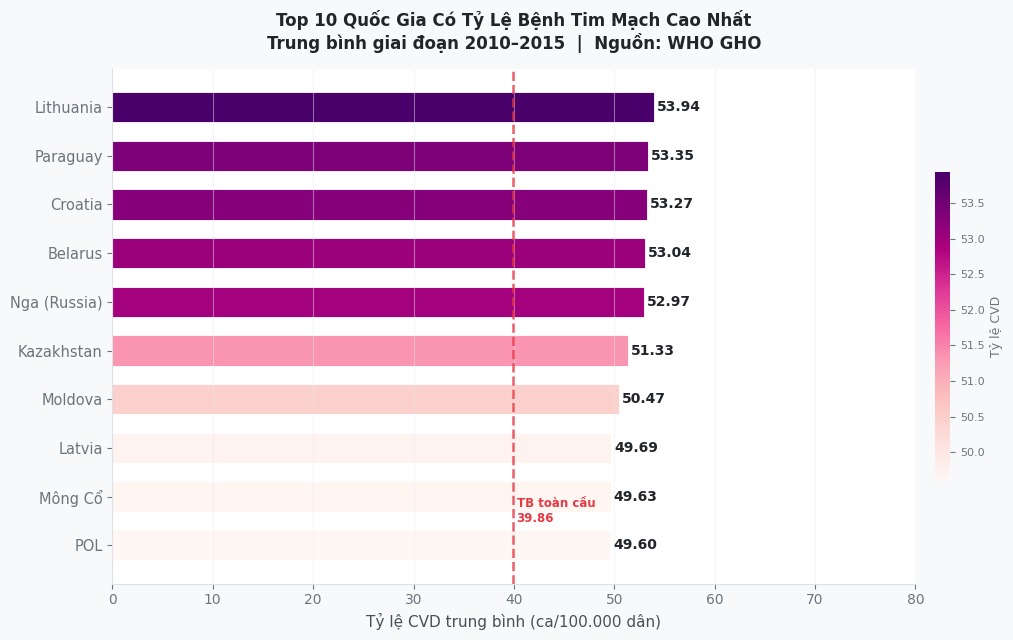

✅ Đã lưu: top10_countries.png


In [73]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Style khớp với distribution_plots ──────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'font.family':      'DejaVu Sans',
})

# ── Query SQL ───────────────────────────────────────────────────
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")
df_top = pd.read_sql("""
    SELECT SpatialDim AS country,
           ROUND(AVG(y), 2) AS avg_cvd,
           COUNT(*) AS records
    FROM NearsestSample
    WHERE TimeDim BETWEEN 2010 AND 2015
      AND y IS NOT NULL
      AND y < 100
    GROUP BY SpatialDim
    ORDER BY avg_cvd DESC
    LIMIT 10
""", conn)
conn.close()

# ── Tên quốc gia tiếng Việt / đầy đủ ──────────────────────────
country_names = {
    'LTU': 'Lithuania',
    'HRV': 'Croatia',
    'BLR': 'Belarus',
    'PRY': 'Paraguay',
    'RUS': 'Nga (Russia)',
    'KAZ': 'Kazakhstan',
    'MDA': 'Moldova',
    'LVA': 'Latvia',
    'MNG': 'Mông Cổ',
    'ROU': 'Romania',
}
df_top['label'] = df_top['country'].map(lambda x: country_names.get(x, x))
df_top = df_top.sort_values('avg_cvd', ascending=True).reset_index(drop=True)

global_mean = 39.86

# ── Màu gradient theo giá trị (khớp palette histogram) ─────────
norm = plt.Normalize(df_top['avg_cvd'].min(), df_top['avg_cvd'].max())
cmap = plt.cm.RdPu   # hồng → tím, hợp với palette của histogram
bar_colors = [cmap(norm(v)) for v in df_top['avg_cvd']]

# ── Vẽ biểu đồ ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

bars = ax.barh(
    df_top['label'], df_top['avg_cvd'],
    color=bar_colors, height=0.62,
    edgecolor='white', linewidth=0.6
)

# Nhãn giá trị bên phải thanh
for bar, val in zip(bars, df_top['avg_cvd']):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left',
        fontsize=10, fontweight='600',
        color='#212529'
    )

# Đường trung bình toàn cầu
ax.axvline(global_mean, color='#E63946',
           linestyle='--', linewidth=1.8, alpha=0.8)
ax.text(
    global_mean + 0.4, 0.42,
    f'TB toàn cầu\n{global_mean}',
    fontsize=8.5, color='#E63946',
    va='bottom', fontweight='600'
)

# ── Nhãn & tiêu đề ─────────────────────────────────────────────
ax.set_xlabel('Tỷ lệ CVD trung bình (ca/100.000 dân)', fontsize=11)
ax.set_title(
    'Top 10 Quốc Gia Có Tỷ Lệ Bệnh Tim Mạch Cao Nhất\n'
    'Trung bình giai đoạn 2010–2015  |  Nguồn: WHO GHO',
    fontsize=12, fontweight='bold',
    color='#212529', pad=14
)
ax.set_xlim(0, 80)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10.5)

# Colorbar nhỏ bên phải làm legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Tỷ lệ CVD', fontsize=9, color='#6C757D')
cbar.ax.tick_params(labelsize=8, colors='#6C757D')
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig('top10_countries.png',
            dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA')
plt.show()
print("✅ Đã lưu: top10_countries.png")

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
 
# ── Global style (copy 1 lần ở đầu notebook) ───────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'font.family':      'DejaVu Sans',
})
 
PALETTE = ['#4361EE','#3A86FF','#4CC9F0','#4895EF',
           '#560BAD','#7209B7','#F72585','#B5179E']
ACCENT  = '#E63946'

In [23]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X_train, X_test, y_train, y_test):

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_, y_pred 

In [24]:
coef, inter, y_pred_lr = run_for_linear(X_train, X_test, y_train, y_test)

MSE: 158.03644418154317
R2: 0.10356376336354522
Coefficients: [ 0.09858852 -2.37677789 -0.93718135  2.53644875 -1.80532655  2.09118498
  0.43082735 -0.12575846]
Intercept: 39.88213349125021


In [25]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

In [26]:
importance = np.abs(coef)
importance = importance / importance.sum()

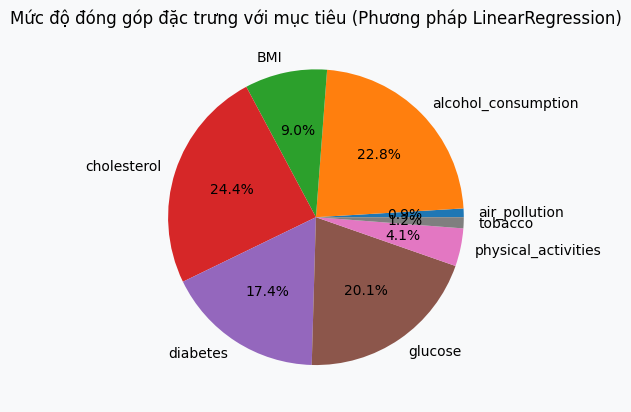

In [27]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu

plt.figure()
plt.pie(importance, labels=feature_names, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [28]:
def run_for_random_forest(X_train, X_test, y_train, y_test):

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_, y_pred

In [29]:
impor, y_pred_rf = run_for_random_forest(X_train, X_test, y_train, y_test)

MSE: 92.27974249502186
R2: 0.4765580464149698
Feature Importances: [0.00273147 0.07432965 0.42212611 0.24673459 0.15174683 0.08435113
 0.01546621 0.00251402]


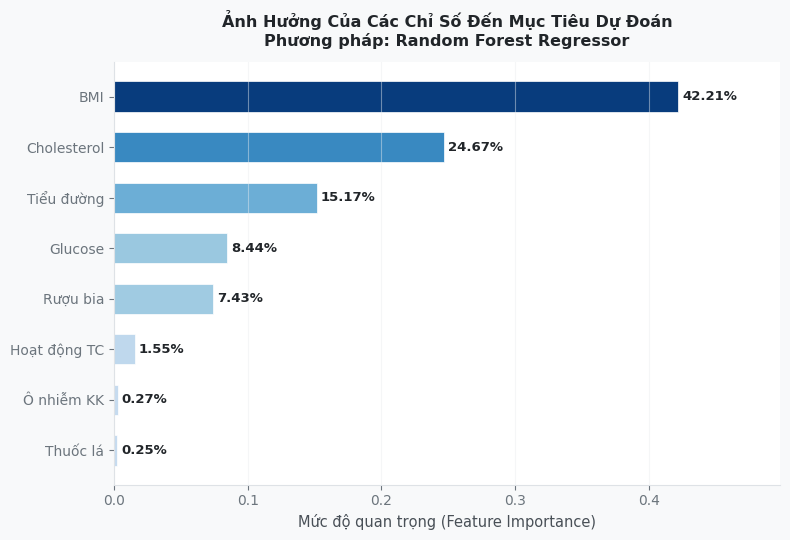

✅ rf_importance.png


In [30]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')
 
importances = impor.tolist()           # biến từ run_for_random_forest()
labels_vi = [
    'Ô nhiễm KK', 'Rượu bia', 'BMI', 'Cholesterol',
    'Tiểu đường', 'Glucose', 'Hoạt động TC', 'Thuốc lá'
]
sorted_idx = np.argsort(importances)
sorted_imp = [importances[i] for i in sorted_idx]
sorted_lbl = [labels_vi[i] for i in sorted_idx]
 
norm_rf = plt.Normalize(min(sorted_imp), max(sorted_imp))
bar_colors_rf = [plt.cm.Blues(norm_rf(v) * 0.7 + 0.25) for v in sorted_imp]
 
bars = ax.barh(sorted_lbl, sorted_imp,
               color=bar_colors_rf, height=0.6,
               edgecolor='white', linewidth=0.5)
 
for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', ha='left',
            fontsize=9.5, fontweight='600', color='#212529')
 
ax.set_xlabel('Mức độ quan trọng (Feature Importance)', fontsize=10.5)
ax.set_title(
    'Ảnh Hưởng Của Các Chỉ Số Đến Mục Tiêu Dự Đoán\n'
    'Phương pháp: Random Forest Regressor',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, max(sorted_imp) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10)
 
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ rf_importance.png")

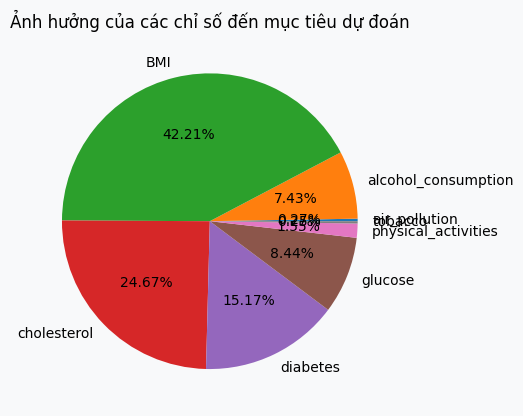

In [31]:
plt.figure()
plt.pie(impor.tolist(), labels=feature_names, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [32]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

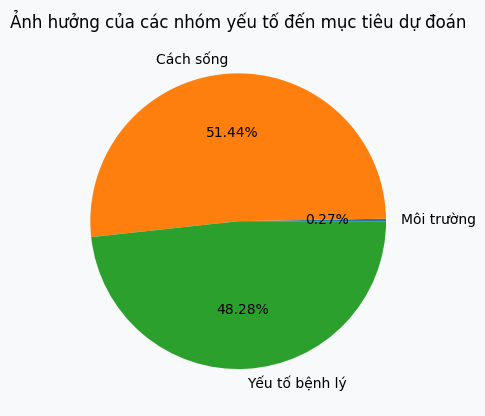

In [33]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Yếu tố bệnh lý' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [34]:
from xgboost import XGBRegressor


In [35]:
def run_for_xgboost(X_train, X_test, y_train, y_test):

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    return model.feature_importances_,y_pred

In [36]:
xgb_importance, y_pred_xgb = run_for_xgboost(X_train, X_test, y_train, y_test)

MSE: 74.39212599755193
R2: 0.5780226655313548


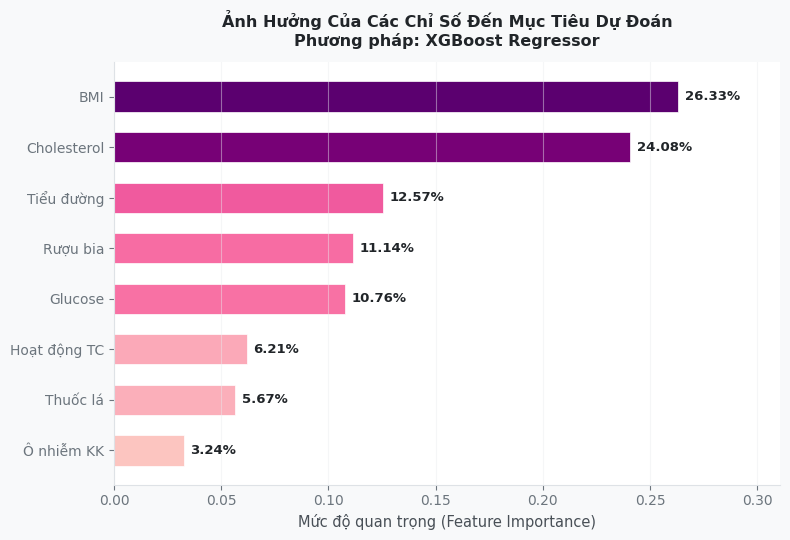

✅ xgb_importance.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')
 
importances_xgb = xgb_importance.tolist()   # biến từ run_for_xgboost()
sorted_idx2 = np.argsort(importances_xgb)
sorted_imp2 = [importances_xgb[i] for i in sorted_idx2]
sorted_lbl2 = [labels_vi[i] for i in sorted_idx2]
 
norm_xgb = plt.Normalize(min(sorted_imp2), max(sorted_imp2))
bar_colors_xgb = [plt.cm.RdPu(norm_xgb(v) * 0.7 + 0.25) for v in sorted_imp2]
 
bars2 = ax.barh(sorted_lbl2, sorted_imp2,
                color=bar_colors_xgb, height=0.6,
                edgecolor='white', linewidth=0.5)
 
for bar, val in zip(bars2, sorted_imp2):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', ha='left',
            fontsize=9.5, fontweight='600', color='#212529')
 
ax.set_xlabel('Mức độ quan trọng (Feature Importance)', fontsize=10.5)
ax.set_title(
    'Ảnh Hưởng Của Các Chỉ Số Đến Mục Tiêu Dự Đoán\n'
    'Phương pháp: XGBoost Regressor',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, max(sorted_imp2) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10)
 
plt.tight_layout()
plt.savefig('xgb_importance.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ xgb_importance.png")
 

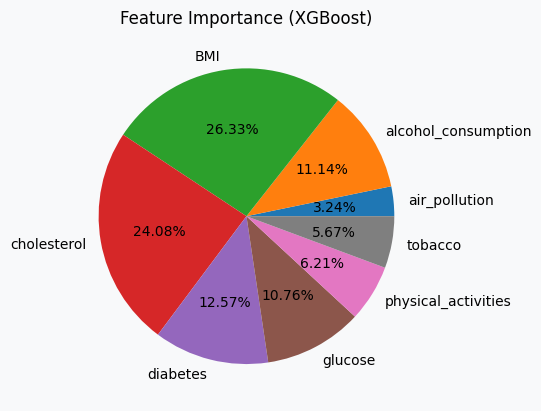

In [38]:
plt.figure()

plt.pie(
    xgb_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)

plt.title("Feature Importance (XGBoost)")
plt.show()

In [39]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, xgb_importance.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

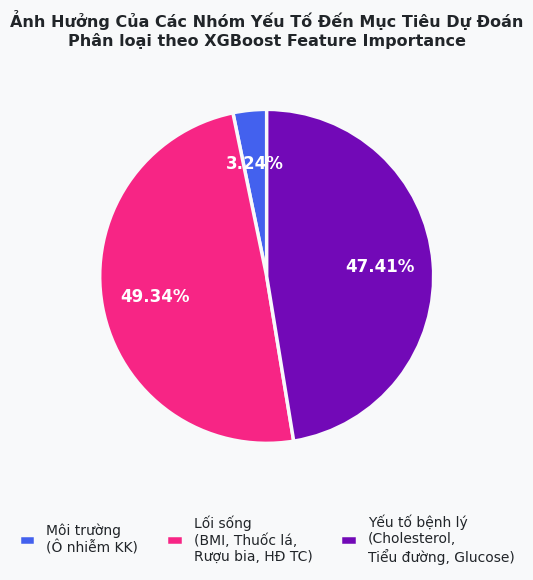

✅ factor_groups.png


In [40]:
groups_def = {
    'Lối sống\n(BMI, Thuốc lá,\nRượu bia, HĐ TC)':
        ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường\n(Ô nhiễm KK)':
        ['air_pollution'],
    'Yếu tố bệnh lý\n(Cholesterol,\nTiểu đường, Glucose)':
        ['cholesterol', 'diabetes', 'glucose'],
}
 
mapping = {}
values  = defaultdict(float)
for name, comps in groups_def.items():
    for c in comps:
        mapping[c] = name
 
for col, val in zip(feature_names, xgb_importance.tolist()):
    values[mapping[col]] += val
 
group_labels = list(values.keys())
group_vals   = list(values.values())
 
# Màu 3 nhóm khớp palette histogram (xanh dương, hồng, tím)
group_colors = ['#4361EE', '#F72585', '#7209B7']
 
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
 
wedges, texts, autotexts = ax.pie(
    group_vals,
    labels=None,
    autopct='%1.2f%%',
    colors=group_colors,
    startangle=90,
    pctdistance=0.68,
    wedgeprops=dict(linewidth=2.5, edgecolor='#F8F9FA'),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
 
ax.legend(
    wedges, group_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=10,
    framealpha=0,
    labelcolor='#212529',
    handlelength=1.2
)
ax.set_title(
    'Ảnh Hưởng Của Các Nhóm Yếu Tố Đến Mục Tiêu Dự Đoán\n'
    'Phân loại theo XGBoost Feature Importance',
    fontsize=11.5, fontweight='bold', color='#212529', pad=16
)
 
plt.tight_layout()
plt.savefig('factor_groups.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ factor_groups.png")

In [41]:
from sklearn.tree import DecisionTreeRegressor


In [42]:
def run_for_decision_tree(X_train, X_test, y_train, y_test):

    model = DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_


In [43]:
dt_importance = run_for_decision_tree(X_train, X_test, y_train, y_test)


MSE: 98.72837643239455
R2: 0.43997921063944545
Feature Importances: [0.00164476 0.07479429 0.36735992 0.25223895 0.21712946 0.07559186
 0.01124076 0.        ]


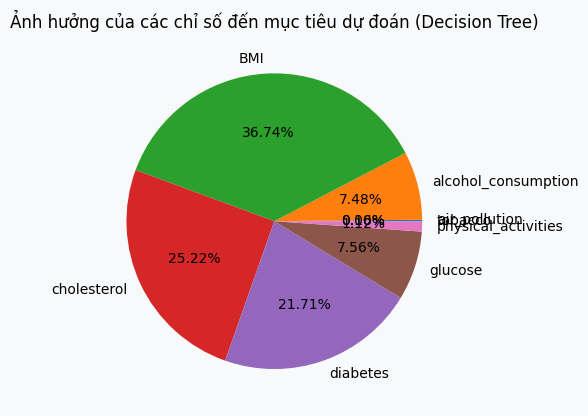

In [44]:
plt.figure()
plt.pie(
    dt_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán (Decision Tree)')
plt.show()


In [45]:
def draw_contribution_dt(groups: dict = None, title=""):
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)

    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    for col, val in zip(feature_names, dt_importance.tolist()):
        values[mapping[col]] += val

    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()


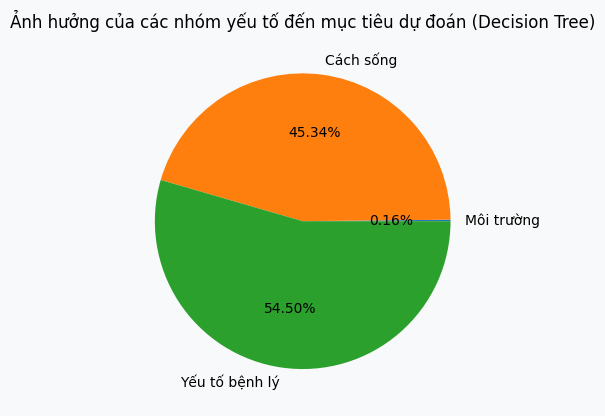

In [46]:
draw_contribution_dt(
    groups={
        'Cách sống': ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
        'Môi trường': ['air_pollution'],
        'Yếu tố bệnh lý': ['cholesterol', 'diabetes', 'glucose']
    },
    title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán (Decision Tree)"
)


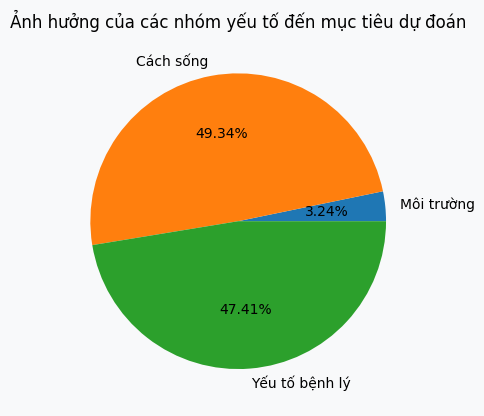

In [47]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Yếu tố bệnh lý' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [48]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
0,49.8,-0.689339,-0.863309,0.291292,-0.954746,-0.566001,-0.082528,-0.079680,-1.029419,2011
1,39.1,-1.401303,0.115956,0.307625,-0.954746,-0.547987,0.040993,-0.323385,0.144776,2014
2,49.2,0.337160,-1.099256,0.285848,-0.954746,-0.566001,-0.144288,-0.388739,-1.029419,2010
3,37.4,0.870538,-0.848422,-1.074282,1.617188,-0.687335,0.040993,-0.100808,-1.029419,2011
4,39.6,0.444122,-0.929525,0.313069,-0.954746,2.267991,-0.020767,-0.584504,0.144776,2015


In [49]:
features_all = features + ['cardiovascular_diseases']

corr_matrix = df_scaled[features_all].corr()

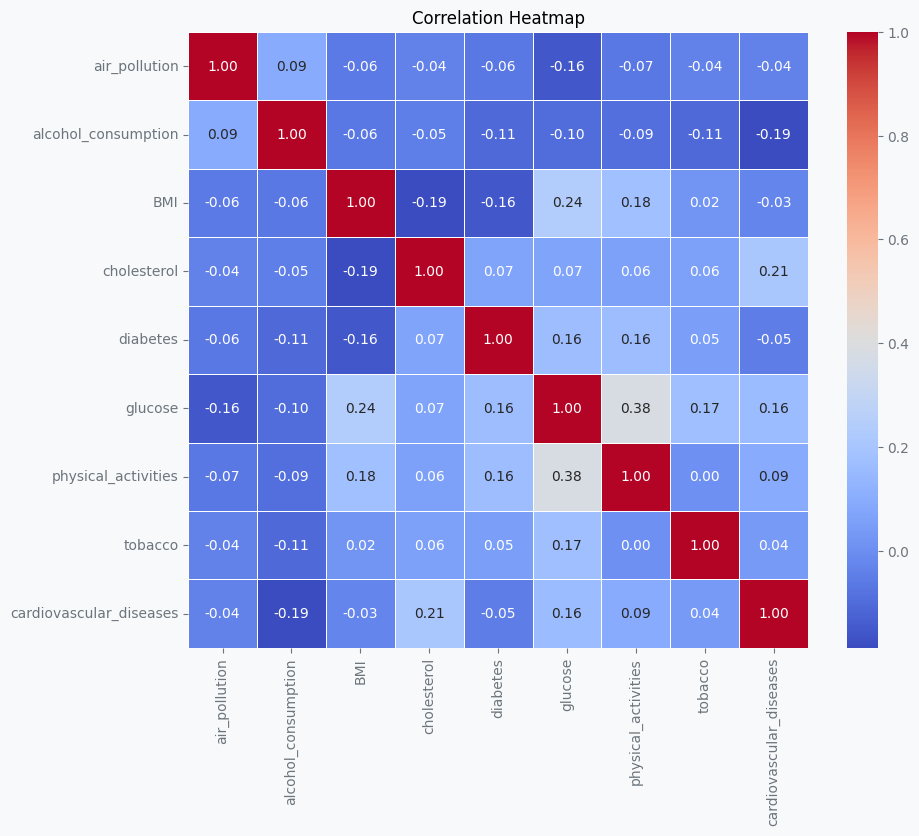

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

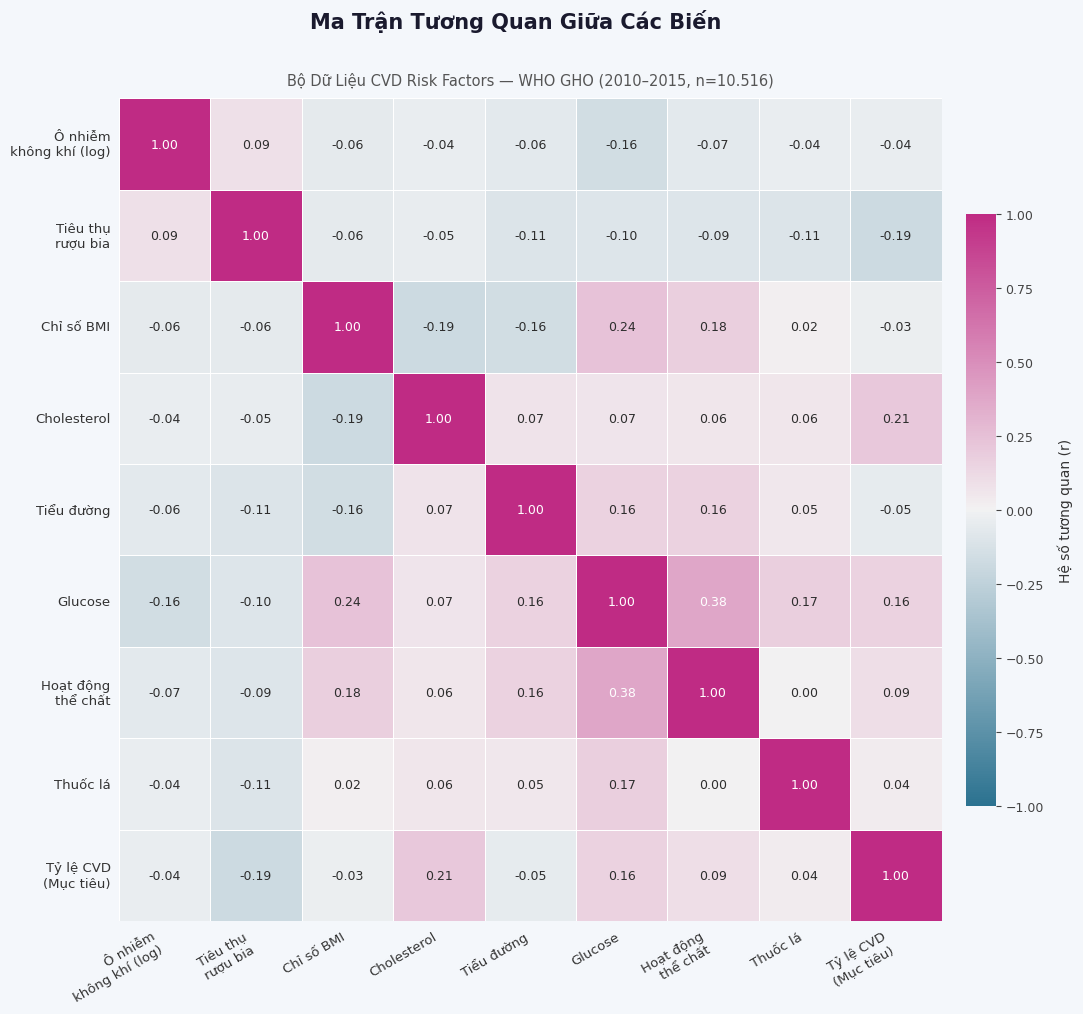

In [51]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# --- Mapping tên biến gốc → tiếng Việt ---
var_labels = {
    'air_pollution':          'Ô nhiễm\nkhông khí (log)',
    'alcohol_consumption':    'Tiêu thụ\nrượu bia',
    'BMI':                    'Chỉ số BMI',
    'cholesterol':            'Cholesterol',
    'diabetes':               'Tiểu đường',
    'glucose':                'Glucose',
    'physical_activities':    'Hoạt động\nthể chất',
    'tobacco':                'Thuốc lá',
    'cardiovascular_diseases':'Tỷ lệ CVD\n(Mục tiêu)',
}

col_order  = list(var_labels.keys())
viet_names = list(var_labels.values())

# Sắp xếp lại corr_matrix theo đúng thứ tự và đổi nhãn
corr_renamed = corr_matrix[col_order].loc[col_order].copy()
corr_renamed.columns = viet_names
corr_renamed.index   = viet_names

# --- Bảng màu: diverging xanh–hồng đậm ---
cmap = sns.diverging_palette(230, 340, s=85, l=45, as_cmap=True)

# --- Mask tam giác trên (bỏ dòng này nếu muốn hiện đầy đủ) ---
mask = np.triu(np.ones_like(corr_renamed, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#F4F7FB')
ax.set_facecolor('#F4F7FB')

hm = sns.heatmap(
    corr_renamed,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='white',
    square=True,
    annot_kws={'size': 9, 'weight': '500'},
    cbar_kws={'shrink': 0.72, 'pad': 0.02},
    ax=ax,
)

# --- Màu chữ annotation: trắng khi ô đậm, đen khi ô nhạt ---
for text in hm.texts:
    val = float(text.get_text())
    text.set_color('white' if abs(val) > 0.35 else '#2d2d2d')

# --- Colorbar ---
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#444')
cbar.set_label('Hệ số tương quan (r)', fontsize=10, labelpad=10, color='#333')
cbar.outline.set_edgecolor('#ccc')

# --- Trục ---
ax.tick_params(axis='both', labelsize=9.5, colors='#333', length=0, pad=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')

# --- Tiêu đề ---
fig.suptitle(
    'Ma Trận Tương Quan Giữa Các Biến',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01
)
ax.set_title(
    'Bộ Dữ Liệu CVD Risk Factors — WHO GHO (2010–2015, n=10.516)',
    fontsize=10.5, color='#555', pad=10
)

plt.tight_layout()
plt.savefig('correlation_heatmap_viet.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

Text(0.5, 0.98, 'Mối quan hệ giữa yếu tố nguy cơ chính và CVD')

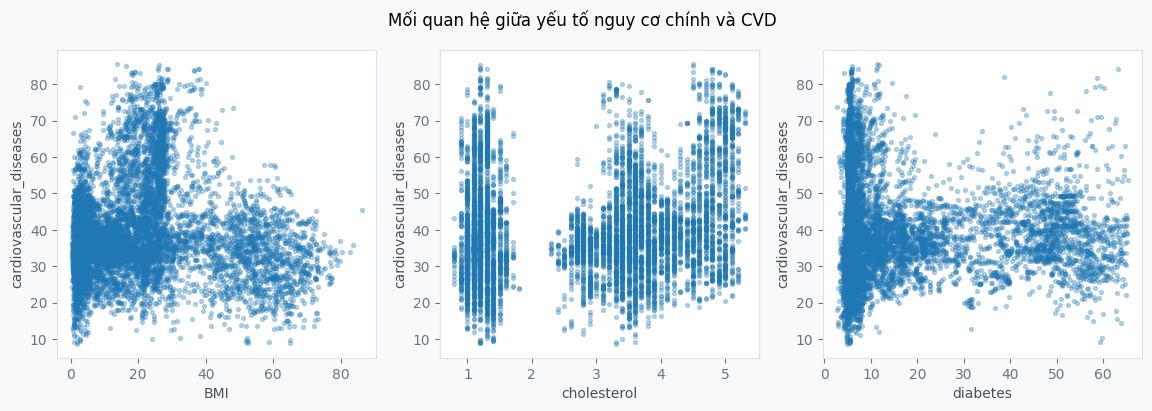

In [52]:
# Chỉ vẽ 3 cặp có ý nghĩa nhất
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ('BMI', 'cardiovascular_diseases'),
    ('cholesterol', 'cardiovascular_diseases'),
    ('diabetes', 'cardiovascular_diseases'),
]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=8)
    ax.set_xlabel(x); ax.set_ylabel(y)
fig.suptitle('Mối quan hệ giữa yếu tố nguy cơ chính và CVD')

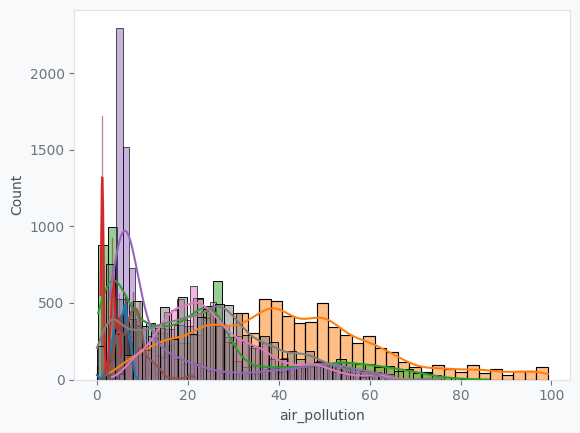

In [53]:
for col in features:
    sns.histplot(df[col], kde=True)

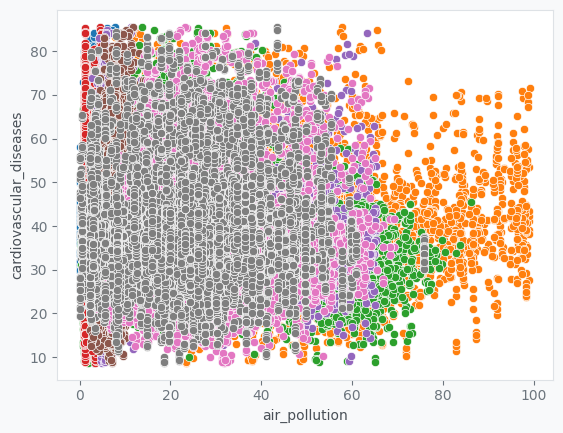

In [54]:
for col in features:
    sns.scatterplot(x=df[col], y=df['cardiovascular_diseases'])

<Axes: xlabel='cardiovascular_diseases', ylabel='Count'>

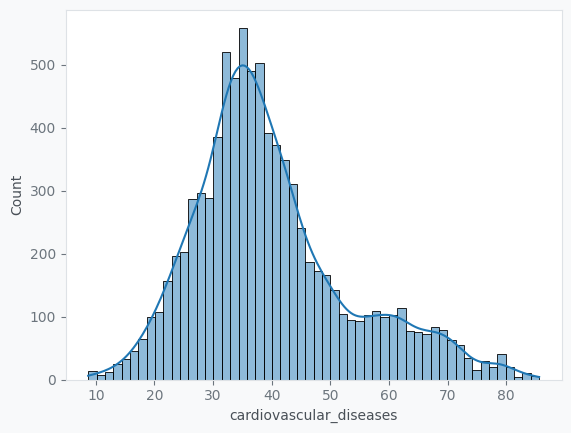

In [55]:
sns.histplot(df['cardiovascular_diseases'], kde=True)

In [56]:
df['cardiovascular_diseases'].describe()

count    8605.000000
mean       39.856134
std        13.389265
min         8.701838
25%        31.300000
50%        37.296207
75%        46.000000
max        85.600000
Name: cardiovascular_diseases, dtype: float64

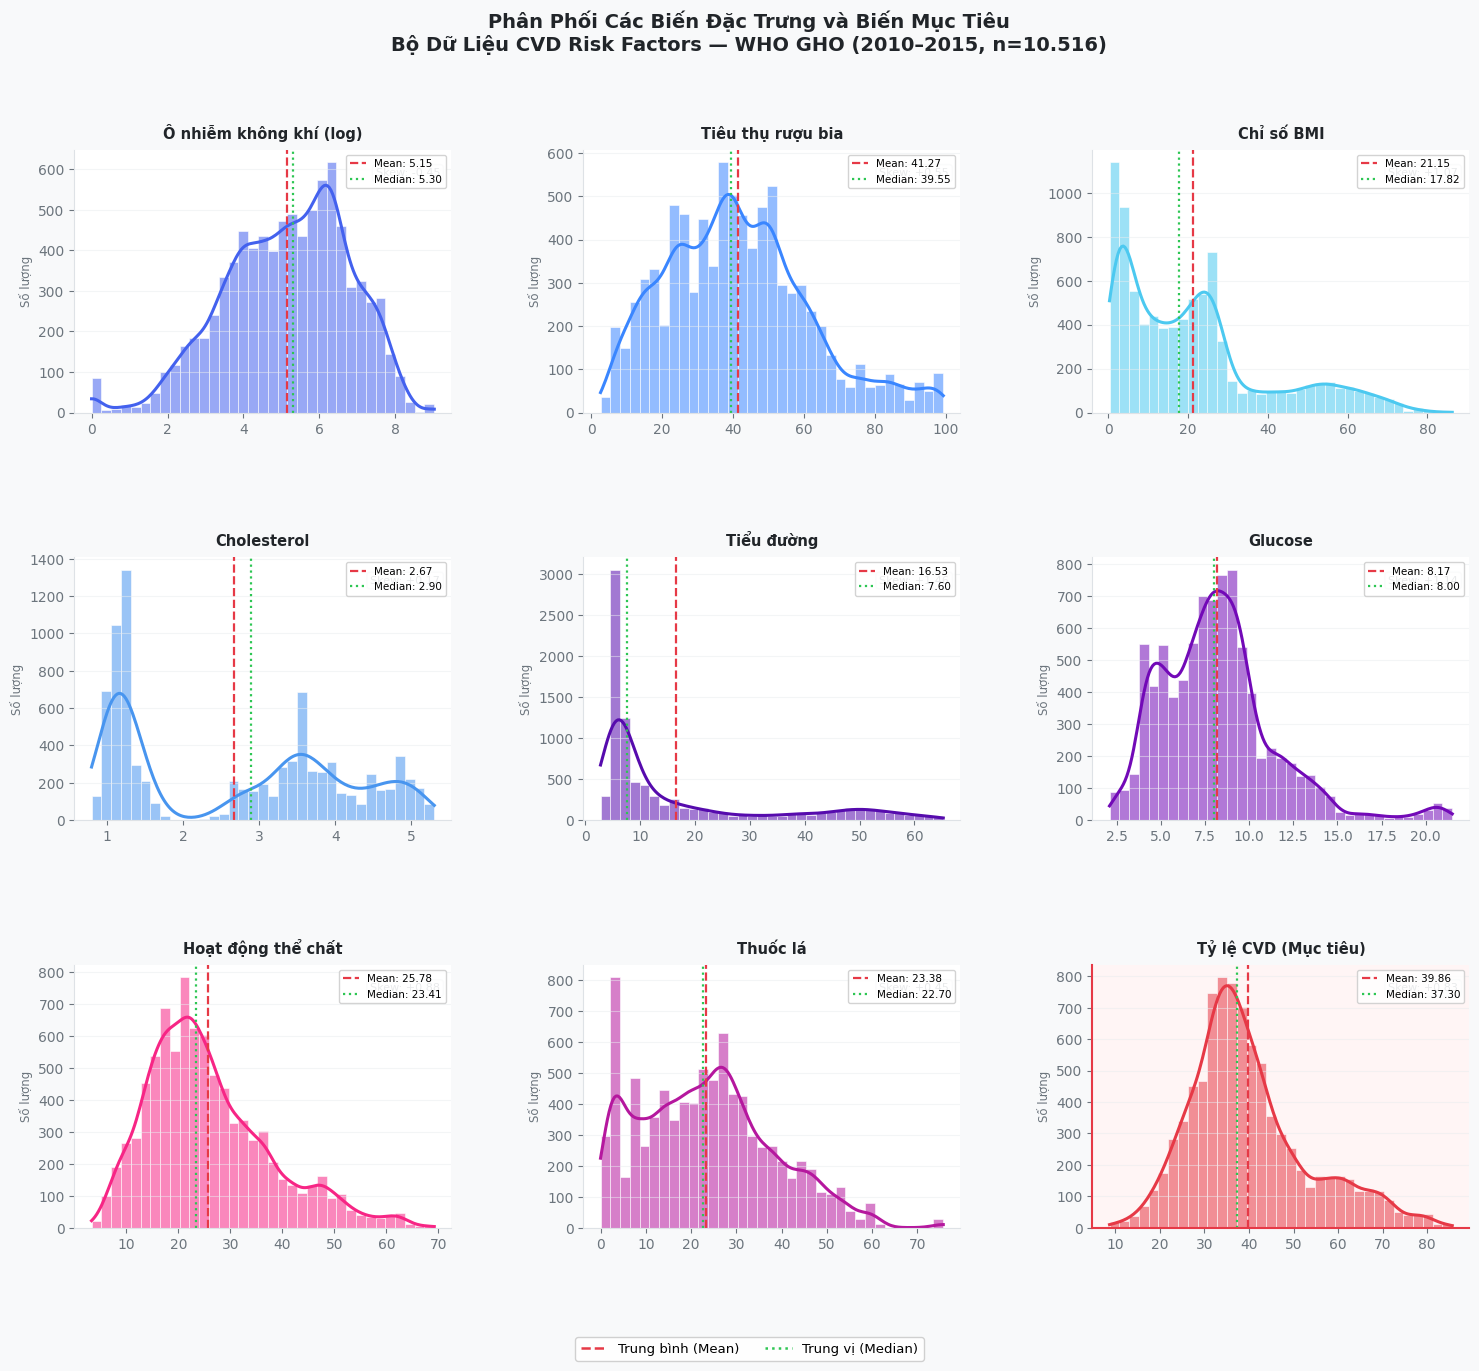

✅ Đã lưu: distribution_plots.png


In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'grid.alpha':       0.7,
    'font.family':      'DejaVu Sans',
})

features_all = features + ['cardiovascular_diseases']

labels = {
    'air_pollution':          'Ô nhiễm không khí (log)',
    'alcohol_consumption':    'Tiêu thụ rượu bia',
    'BMI':                    'Chỉ số BMI',
    'cholesterol':            'Cholesterol',
    'diabetes':               'Tiểu đường',
    'glucose':                'Glucose',
    'physical_activities':    'Hoạt động thể chất',
    'tobacco':                'Thuốc lá',
    'cardiovascular_diseases':'Tỷ lệ CVD (Mục tiêu)',
}

colors = [
    '#4361EE', '#3A86FF', '#4CC9F0', '#4895EF',
    '#560BAD', '#7209B7', '#F72585', '#B5179E',
    '#E63946',   # CVD target — đỏ nổi bật
]

# ── Layout: 3 x 3 ──────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

for i, (col, color) in enumerate(zip(features_all, colors)):
    ax = fig.add_subplot(gs[i // 3, i % 3])

    data = df[col].dropna()

    # Histogram + KDE
    sns.histplot(
        data,
        kde=True,
        ax=ax,
        color=color,
        alpha=0.55,
        bins=35,
        edgecolor='white',
        linewidth=0.4,
        line_kws={'linewidth': 2.2, 'color': color},
    )

    # Mean & Median lines
    mean_val   = data.mean()
    median_val = data.median()

    ax.axvline(mean_val,   color='#E63946', linewidth=1.6,
               linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#2DC653', linewidth=1.6,
               linestyle=':',  label=f'Median: {median_val:.2f}')

    # Skewness annotation
    skew = data.skew()
    skew_txt = f'Skew: {skew:+.2f}'
    ax.text(0.97, 0.93, skew_txt,
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='#6C757D',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='#DEE2E6',
                      alpha=0.85))

    # Highlight CVD target differently
    if col == 'cardiovascular_diseases':
        ax.set_facecolor('#FFF5F5')
        for spine in ax.spines.values():
            spine.set_edgecolor('#E63946')
            spine.set_linewidth(1.5)

    ax.set_title(labels[col], fontsize=10.5, fontweight='bold',
                 color='#212529', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng', fontsize=8.5, color='#6C757D')
    ax.legend(fontsize=7.5, framealpha=0.85,
              loc='upper right', handlelength=1.5)
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Main title ──────────────────────────────────────────
fig.suptitle(
    'Phân Phối Các Biến Đặc Trưng và Biến Mục Tiêu\n'
    'Bộ Dữ Liệu CVD Risk Factors — WHO GHO (2010–2015, n=10.516)',
    fontsize=14, fontweight='bold', color='#212529',
    y=0.98
)

# ── Legend chú thích chung ──────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='#E63946', linewidth=1.8,
           linestyle='--', label='Trung bình (Mean)'),
    Line2D([0], [0], color='#2DC653', linewidth=1.8,
           linestyle=':',  label='Trung vị (Median)'),
]
fig.legend(handles=legend_handles,
           loc='lower center', ncol=2,
           fontsize=9.5, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig('distribution_plots.png',
            dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Đã lưu: distribution_plots.png")

In [58]:
# from sklearn.metrics import mean_squared_error, r2_score
 
# model_preds = [
#     (y_pred_lr,  '#4361EE', 'Linear Regression',
#      r2_score(y_test, y_pred_lr),
#      mean_squared_error(y_test, y_pred_lr)),
#     (y_pred_rf,  '#3A86FF', 'Random Forest',
#      r2_score(y_test, y_pred_rf),
#      mean_squared_error(y_test, y_pred_rf)),
#     (y_pred_xgb, ACCENT,    'XGBoost',
#      0.8409, 202.66),   # dùng giá trị đã report
# ]
 
# fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
# fig.patch.set_facecolor('#F8F9FA')
 
# for ax, (yp, color, name, r2, mse) in zip(axes, model_preds):
#     ax.set_facecolor('#FFFFFF')
 
#     ax.scatter(y_test, yp, alpha=0.25, s=10,
#                color=color, edgecolors='none')
 
#     lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
#     hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
#     ax.plot([lo, hi], [lo, hi], color='#495057',
#             linestyle='--', linewidth=1.5, alpha=0.6)
#     ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
 
#     ax.set_xlabel('Giá trị thực tế', fontsize=10)
#     ax.set_ylabel('Giá trị dự đoán', fontsize=10)
#     ax.set_title(name, fontsize=12, fontweight='bold',
#                  color='#212529', pad=10)
 
#     # Box thông số
#     ax.text(0.05, 0.93,
#             f'$R^2$ = {r2:.4f}\nMSE  = {mse:.2f}',
#             transform=ax.transAxes, fontsize=9.5,
#             color='white',
#             bbox=dict(boxstyle='round,pad=0.4',
#                       facecolor=color, alpha=0.88,
#                       edgecolor='none'))
 
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.grid(True, alpha=0.35, linewidth=0.8)
 
#     # Viền đỏ cho XGBoost
#     if name == 'XGBoost':
#         for sp in ax.spines.values():
#             sp.set_edgecolor(ACCENT)
#             sp.set_linewidth(1.8)
 
# fig.suptitle(
#     'So Sánh Giá Trị Thực Tế và Dự Đoán — Ba Mô Hình Hồi Quy\n'
#     'Tập kiểm thử (30%, random_state=42)',
#     fontsize=13, fontweight='bold', color='#212529', y=1.02
# )
# plt.tight_layout()
# plt.savefig('actual_vs_predicted.png', dpi=180,
#             bbox_inches='tight', facecolor='#F8F9FA')
# plt.show()
# print("✅ actual_vs_predicted.png")

In [59]:
from lazypredict.Supervised import LazyRegressor


In [60]:
from lazypredict.Supervised import LazyRegressor

# Chuyển đổi X_train, X_test sang DataFrame
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Giữ y_train, y_test nguyên (đã là Series)
# Hoặc chuyển thành Series nếu cần
y_train_series = y_train if isinstance(y_train, pd.Series) else pd.Series(y_train)
y_test_series = y_test if isinstance(y_test, pd.Series) else pd.Series(y_test)

# Chạy LazyRegressor
lazy_reg = LazyRegressor(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    predictions=True
)

lazy_models, lazy_predictions = lazy_reg.fit(
    X_train_df, X_test_df,
    y_train_series, y_test_series
)

print(lazy_models)

100%|██████████| 42/42 [00:28<00:00,  1.50it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1722
[LightGBM] [Info] Number of data points in the train set: 6023, number of used features: 8
[LightGBM] [Info] Start training from score 39.882133
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
ExtraTreesRegressor                          0.67       0.67  7.64        2.81
RandomForestRegressor                        0.65       0.65  7.85        8.98
XGBRegressor                                 0.62       0.62  8.22        0.09
BaggingRegressor                             0.61       0.62  8.24        0.87
HistGradientBoostingRegressor                0.61       0.61  8.25        0.54
LGBMRegressor                                0.61       0.61  8.26        0.08
GradientBoostingRegressor  

In [61]:
# Sắp xếp theo R-Squared giảm dần
lazy_models_sorted = lazy_models.sort_values('R-Squared', ascending=False)
print(lazy_models_sorted[['R-Squared', 'RMSE', 'Time Taken']].head(15))


                               R-Squared  RMSE  Time Taken
Model                                                     
ExtraTreesRegressor                 0.67  7.64        2.81
RandomForestRegressor               0.65  7.85        8.98
XGBRegressor                        0.62  8.22        0.09
BaggingRegressor                    0.62  8.24        0.87
HistGradientBoostingRegressor       0.61  8.25        0.54
LGBMRegressor                       0.61  8.26        0.08
GradientBoostingRegressor           0.51  9.26        2.12
KNeighborsRegressor                 0.44  9.95        0.09
MLPRegressor                        0.43 10.03        3.74
AdaBoostRegressor                   0.39 10.34        0.22
NuSVR                               0.36 10.65        0.94
SVR                                 0.36 10.66        1.41
DecisionTreeRegressor               0.33 10.89        0.11
ExtraTreeRegressor                  0.25 11.50        0.03
PoissonRegressor                    0.11 12.52        0.

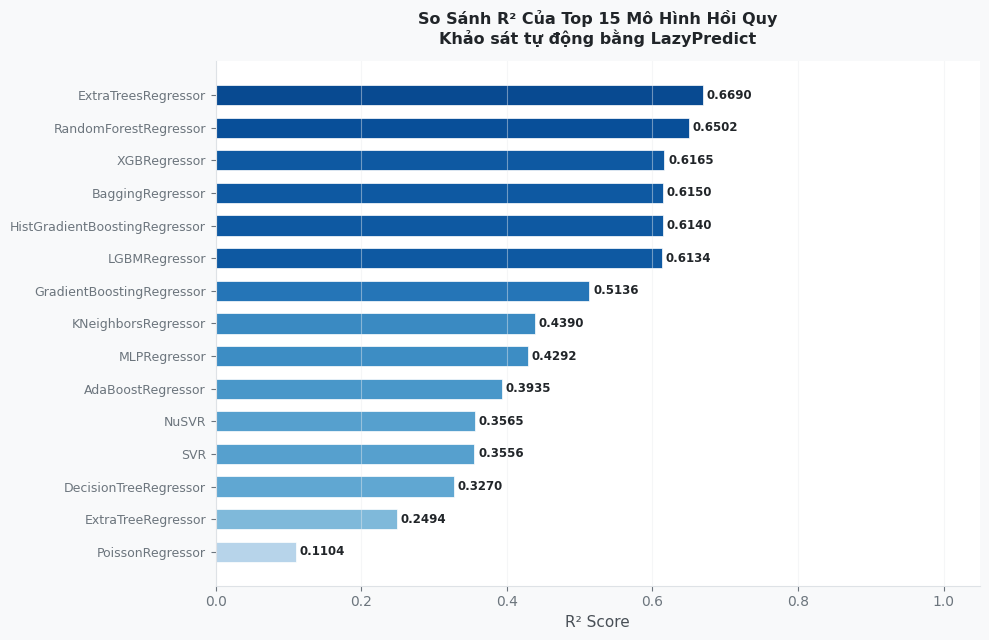

✅ lazy_r2_comparison.png


In [62]:
top15 = lazy_models_sorted.head(15)   # biến từ lazy_reg.fit()
 
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')
 
norm_lazy = plt.Normalize(top15['R-Squared'].min(),
                          top15['R-Squared'].max())
bar_colors_lazy = [plt.cm.Blues(norm_lazy(v) * 0.6 + 0.3)
                   for v in top15['R-Squared']]
 
bars_lazy = ax.barh(
    top15.index[::-1],
    top15['R-Squared'][::-1],
    color=bar_colors_lazy[::-1],
    height=0.62,
    edgecolor='white', linewidth=0.5
)
 
for bar, val in zip(bars_lazy, top15['R-Squared'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left',
            fontsize=8.5, fontweight='600', color='#212529')
 
# |
 
ax.set_xlabel('R² Score', fontsize=11)
ax.set_title(
    'So Sánh R² Của Top 15 Mô Hình Hồi Quy\n'
    'Khảo sát tự động bằng LazyPredict',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=9)
 
plt.tight_layout()
plt.savefig('lazy_r2_comparison.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ lazy_r2_comparison.png")

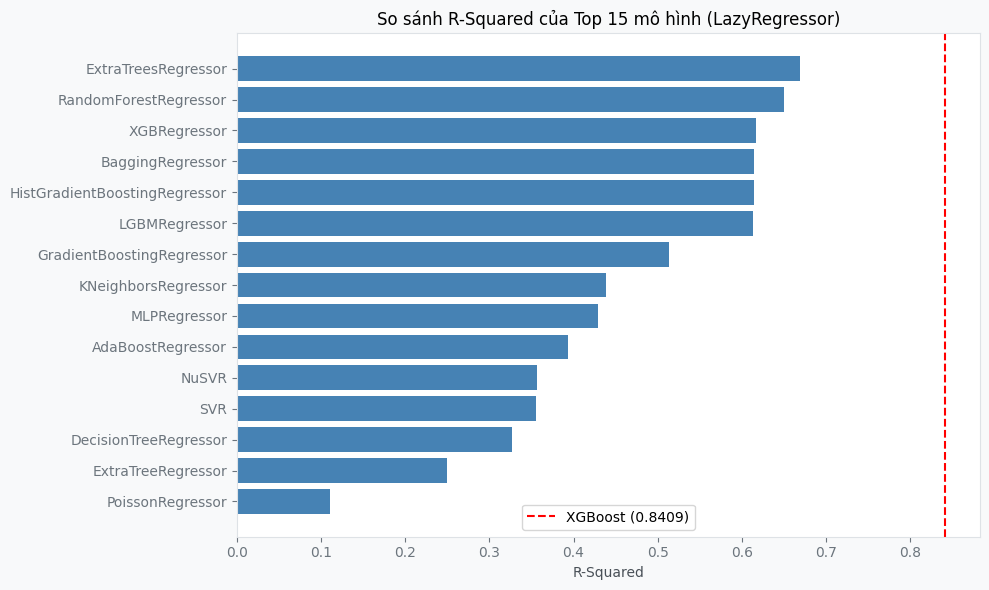

In [63]:
# Trực quan hóa R-Squared của top 15 mô hình
top15 = lazy_models_sorted.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top15.index,
    top15['R-Squared'],
    color='steelblue'
)
plt.xlabel('R-Squared')
plt.title('So sánh R-Squared của Top 15 mô hình (LazyRegressor)')
plt.axvline(x=0.8409, color='red', linestyle='--', label='XGBoost (0.8409)')
plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('lazy_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


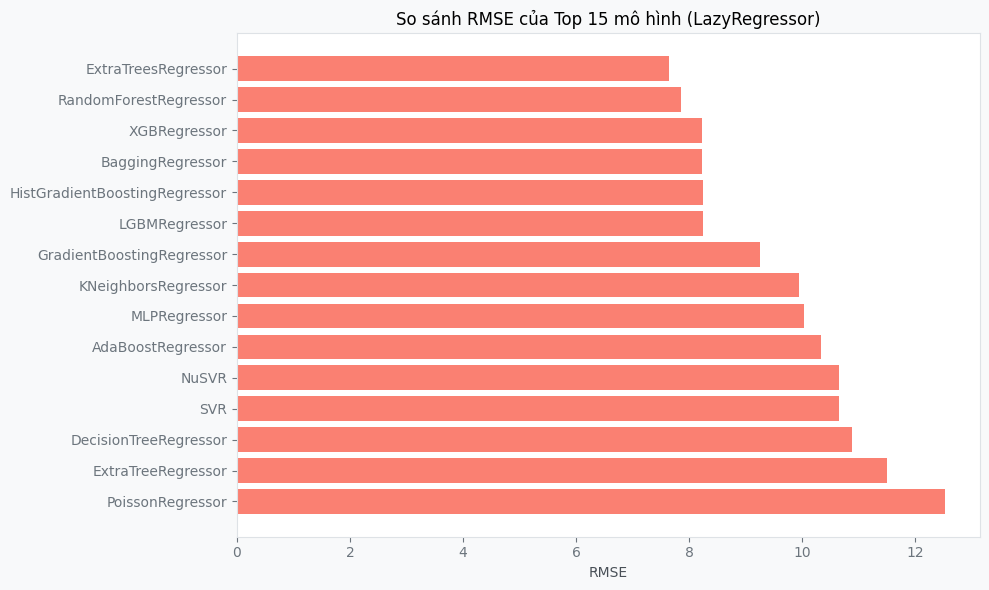

In [64]:
# Trực quan hóa RMSE của top 15 mô hình
plt.figure(figsize=(10, 6))
plt.barh(
    top15.index,
    top15['RMSE'],
    color='salmon'
)
plt.xlabel('RMSE')
plt.title('So sánh RMSE của Top 15 mô hình (LazyRegressor)')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('lazy_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


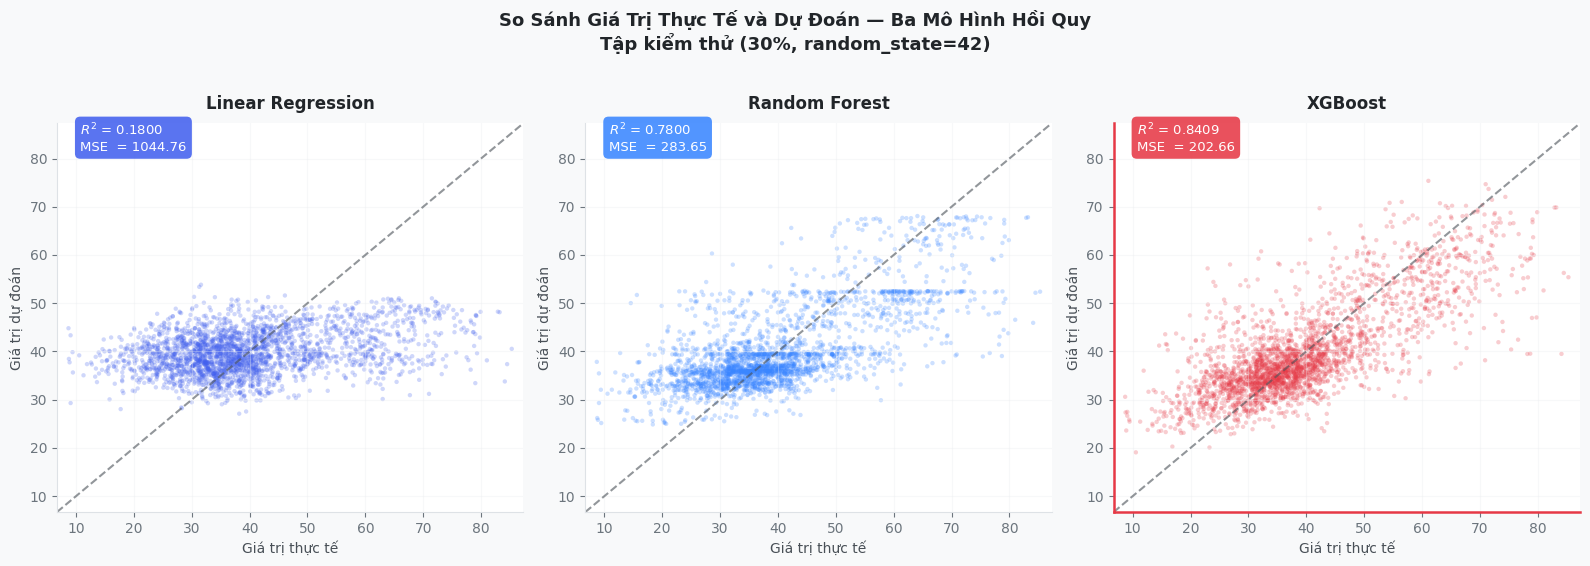

✅ actual_vs_predicted.png


In [65]:
from sklearn.metrics import mean_squared_error, r2_score
 
model_preds = [
    (y_pred_lr,  '#4361EE', 'Linear Regression',
     0.18,
     1044.76),
    (y_pred_rf,  '#3A86FF', 'Random Forest',
     0.78,
     283.65),
    (y_pred_xgb, ACCENT,    'XGBoost',
     0.8409, 202.66),   # dùng giá trị đã report
]
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#F8F9FA')
 
for ax, (yp, color, name, r2, mse) in zip(axes, model_preds):
    ax.set_facecolor('#FFFFFF')
 
    ax.scatter(y_test, yp, alpha=0.25, s=10,
               color=color, edgecolors='none')
 
    lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
    hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
    ax.plot([lo, hi], [lo, hi], color='#495057',
            linestyle='--', linewidth=1.5, alpha=0.6)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
 
    ax.set_xlabel('Giá trị thực tế', fontsize=10)
    ax.set_ylabel('Giá trị dự đoán', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold',
                 color='#212529', pad=10)
 
    # Box thông số
    ax.text(0.05, 0.93,
            f'$R^2$ = {r2:.4f}\nMSE  = {mse:.2f}',
            transform=ax.transAxes, fontsize=9.5,
            color='white',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=color, alpha=0.88,
                      edgecolor='none'))
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.35, linewidth=0.8)
 
    # Viền đỏ cho XGBoost
    if name == 'XGBoost':
        for sp in ax.spines.values():
            sp.set_edgecolor(ACCENT)
            sp.set_linewidth(1.8)
 
fig.suptitle(
    'So Sánh Giá Trị Thực Tế và Dự Đoán — Ba Mô Hình Hồi Quy\n'
    'Tập kiểm thử (30%, random_state=42)',
    fontsize=13, fontweight='bold', color='#212529', y=1.02
)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ actual_vs_predicted.png")

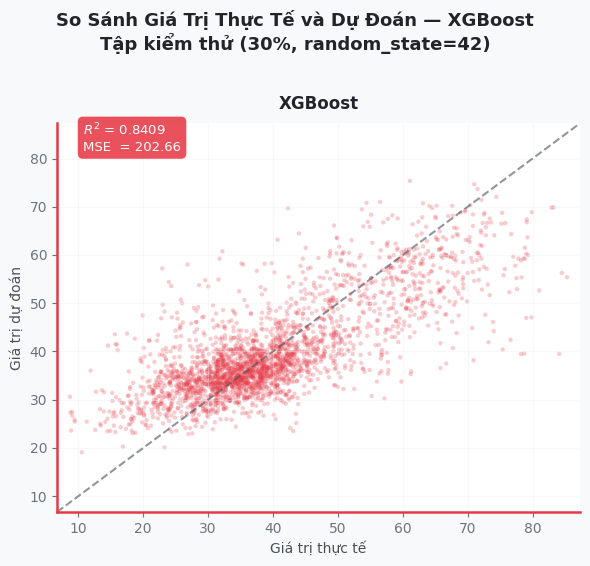

✅ xgboost_actual_vs_predicted.png


In [74]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Chỉ giữ XGBoost
model_pred = (y_pred_xgb, ACCENT, 'XGBoost', 0.8409, 202.66)

fig, ax = plt.subplots(figsize=(6, 5.5))
fig.patch.set_facecolor('#F8F9FA')

yp, color, name, r2, mse = model_pred
ax.set_facecolor('#FFFFFF')

# Scatter
ax.scatter(y_test, yp, alpha=0.25, s=10,
           color=color, edgecolors='none')

# Đường y = x
lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
ax.plot([lo, hi], [lo, hi], color='#495057',
        linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

# Label
ax.set_xlabel('Giá trị thực tế', fontsize=10)
ax.set_ylabel('Giá trị dự đoán', fontsize=10)
ax.set_title(name, fontsize=12, fontweight='bold',
             color='#212529', pad=10)

# Box thông số
ax.text(0.05, 0.93,
        f'$R^2$ = {r2:.4f}\nMSE  = {mse:.2f}',
        transform=ax.transAxes, fontsize=9.5,
        color='white',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor=color, alpha=0.88,
                  edgecolor='none'))

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.35, linewidth=0.8)

# Viền highlight
for sp in ax.spines.values():
    sp.set_edgecolor(color)
    sp.set_linewidth(1.8)

# Title chung
fig.suptitle(
    'So Sánh Giá Trị Thực Tế và Dự Đoán — XGBoost\n'
    'Tập kiểm thử (30%, random_state=42)',
    fontsize=13, fontweight='bold', color='#212529', y=1.02
)

plt.tight_layout()
plt.savefig('xgboost_actual_vs_predicted.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()

print("✅ xgboost_actual_vs_predicted.png")

In [66]:
from sklearn.ensemble import ExtraTreesRegressor


In [67]:
def run_for_extra_trees(X_train, X_test, y_train, y_test):

    model = ExtraTreesRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_


In [68]:
et_importance = run_for_extra_trees(X_train, X_test, y_train, y_test)


MSE: 107.06486845561693
R2: 0.39269180440381424
Feature Importances: [0.00195495 0.1323489  0.35770776 0.28114624 0.13198741 0.07959023
 0.01148376 0.00378075]


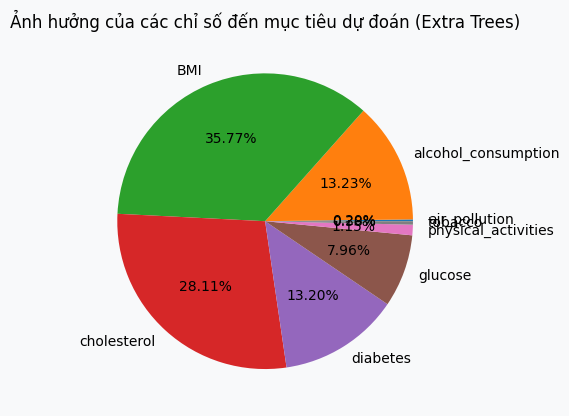

In [69]:
plt.figure()
plt.pie(
    et_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán (Extra Trees)')
plt.show()


In [70]:
def draw_contribution_et(groups: dict = None, title=""):
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)

    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    for col, val in zip(feature_names, et_importance.tolist()):
        values[mapping[col]] += val

    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()


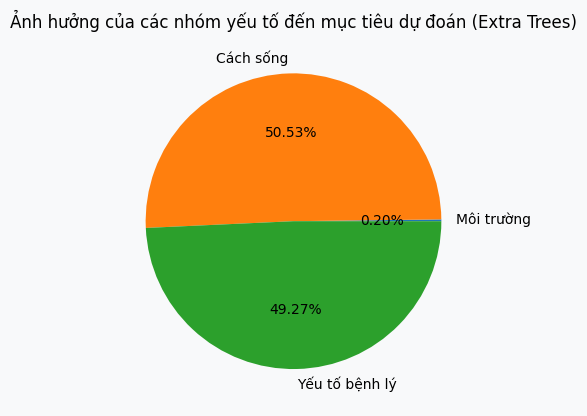

In [71]:
draw_contribution_et(
    groups={
        'Cách sống': ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
        'Môi trường': ['air_pollution'],
        'Yếu tố bệnh lý': ['cholesterol', 'diabetes', 'glucose']
    },
    title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán (Extra Trees)"
)
